# ECON4002 — Week 8: Producer Theory II: Profit Maximization & Industry R Code

**University of Western Australia**  
*R implementations for profit maximization, supply curves, industry equilibrium, and producer surplus*

---

## Key Formulae

Cost function: $C(q) = wL^*(q) + rK^*(q)$. MC: $\frac{dC}{dq}$. AC: $\frac{C(q)}{q}$

---

> **How to use:** Run each cell in order. Modify the parameters and re-run to explore the economics.

In [ ]:
# ECON4002 Week 8 — R Setup
# Run this cell first to configure options
options(scipen = 6, digits = 4)
cat('Week 8: Producer Theory II: Profit Maximization & Industry R Code — ready!\n')

Week 8: Producer Theory II: Profit Maximization & Industry R Code — ready!


## Profit Max

### W8-CS01 — Profit Maximization - Output Choice

> **Note:** At optimum: p = MC. Profit = py - C(y).

In [ ]:
# Profit maximization given cost function
profit_max_output <- function(p, cost_fn, y_range = c(0.1, 100)) {
  # Objective: maximize profit
  profit <- function(y) p * y - cost_fn(y)
  
  # Find optimal output
  result <- optimize(profit, interval = y_range, maximum = TRUE)
  
  y_star <- result$maximum
  pi_star <- result$objective
  
  return(list(
    y_star = y_star,
    profit = pi_star,
    revenue = p * y_star,
    cost = cost_fn(y_star),
    MC = (cost_fn(y_star + 0.001) - cost_fn(y_star - 0.001)) / 0.002
  ))
}

# Test with quadratic cost
cost_fn <- function(y) 50 + 2*y + 0.5*y^2
result <- profit_max_output(p = 12, cost_fn)

cat('Optimal output:', round(result$y_star, 2), '\n')
cat('Profit:', round(result$profit, 2), '\n')
cat('MC at optimum:', round(result$MC, 2), '(should = p = 12)')

### W8-CS02 — VMP Condition - Single Input

> **Note:** Hire labor until VMP_L = w. For y = 100√L, MP_L = 50/√L.

In [ ]:
# Profit maximization using VMP = w
vmp_profit_max <- function(p, w, prod_fn, L_range = c(0.1, 100)) {
  # Production: y = f(L)
  # Profit: π = p·f(L) - wL
  
  profit <- function(L) p * prod_fn(L) - w * L
  
  result <- optimize(profit, interval = L_range, maximum = TRUE)
  L_star <- result$maximum
  
  # Numerical MP
  h <- 0.001
  MP_L <- (prod_fn(L_star + h) - prod_fn(L_star - h)) / (2 * h)
  VMP_L <- p * MP_L
  
  return(list(
    L_star = L_star,
    y_star = prod_fn(L_star),
    profit = result$objective,
    VMP = VMP_L,
    wage = w,
    check_VMP_eq_w = abs(VMP_L - w) < 0.1
  ))
}

# Test: Q = 100√L
result <- vmp_profit_max(p = 8, w = 200, prod_fn = function(L) 100 * sqrt(L))

cat('L*:', round(result$L_star, 2), '\n')
cat('y*:', round(result$y_star, 2), '\n')
cat('Profit:', round(result$profit, 2), '\n')
cat('VMP:', round(result$VMP, 2), ', w:', result$wage, '\n')
cat('VMP = w?', result$check_VMP_eq_w)

### W8-CS03 — Two-Input Profit Maximization

> **Note:** With DRS (α+β<1), there's a finite optimal scale. VMP_L = w, VMP_K = r at optimum.

In [ ]:
# Profit maximization with two inputs
profit_max_2inputs <- function(p, w, r, alpha, beta, A = 1) {
  # f(L,K) = A·L^α·K^β
  # Need α + β < 1 for interior solution
  
  if (alpha + beta >= 1) {
    warning('Need α + β < 1 for bounded solution')
    return(NULL)
  }
  
  profit <- function(x) {
    L <- x[1]; K <- x[2]
    if (L <= 0 || K <= 0) return(-1e10)
    y <- A * L^alpha * K^beta
    p * y - w * L - r * K
  }
  
  result <- optim(c(1, 1), profit, method = 'L-BFGS-B',
                  lower = c(0.01, 0.01), control = list(fnscale = -1))
  
  L_star <- result$par[1]
  K_star <- result$par[2]
  y_star <- A * L_star^alpha * K_star^beta
  pi_star <- -result$value  # optim minimizes, we want max
  pi_star <- p * y_star - w * L_star - r * K_star
  
  # Check VMP conditions
  VMP_L <- p * alpha * A * L_star^(alpha-1) * K_star^beta
  VMP_K <- p * beta * A * L_star^alpha * K_star^(beta-1)
  
  cat('=== Two-Input Profit Max ===\n')
  cat('L*:', round(L_star, 3), '\n')
  cat('K*:', round(K_star, 3), '\n')
  cat('y*:', round(y_star, 3), '\n')
  cat('π*:', round(pi_star, 3), '\n')
  cat('VMP_L:', round(VMP_L, 3), ', w:', w, '\n')
  cat('VMP_K:', round(VMP_K, 3), ', r:', r, '\n')
  
  return(list(L = L_star, K = K_star, y = y_star, profit = pi_star))
}

# Test
profit_max_2inputs(p = 50, w = 10, r = 20, alpha = 0.3, beta = 0.2)

## Supply

### W8-CS04 — Derive Supply Curve

> **Note:** Supply = MC curve above shutdown point (min AVC in SR, min AC in LR).

In [ ]:
# Derive supply curve from cost function
derive_supply <- function(cost_fn, p_range = c(1, 50), n_points = 100) {
  p_seq <- seq(p_range[1], p_range[2], length = n_points)
  y_seq <- numeric(n_points)
  
  for (i in seq_along(p_seq)) {
    p <- p_seq[i]
    # Find y where MC = p
    result <- profit_max_output(p, cost_fn, y_range = c(0.01, 200))
    
    # Check shutdown condition (p >= min AVC)
    y <- result$y_star
    VC <- cost_fn(y) - cost_fn(0.001)  # Approximate VC
    AVC <- VC / y
    
    if (p >= AVC) {
      y_seq[i] <- y
    } else {
      y_seq[i] <- 0
    }
  }
  
  return(data.frame(p = p_seq, y = y_seq))
}

# Cost function: C(y) = 100 + 10y + y²
cost_fn <- function(y) 100 + 10*y + y^2
supply_data <- derive_supply(cost_fn, p_range = c(5, 40))

# Plot
plot(supply_data$y, supply_data$p, type = 'l', lwd = 2, col = 'blue',
     xlab = 'Quantity (y)', ylab = 'Price (p)',
     main = 'Supply Curve')
grid()
abline(h = 10, lty = 2, col = 'red')  # min AVC
text(5, 12, 'min AVC', col = 'red')

### W8-CS05 — Short-Run vs Long-Run Supply

> **Note:** SR: operate if p ≥ min AVC. LR: operate if p ≥ min AC.

In [ ]:
# Compare SR and LR supply curves
sr_lr_supply <- function(FC = 100, a = 10, b = 1, p_max = 50) {
  # Cost: C(y) = FC + ay + by²
  # MC = a + 2by
  # VC = ay + by², AVC = a + by
  # AC = FC/y + a + by
  
  p_seq <- seq(1, p_max, length = 200)
  
  # Min AVC = a (as y → 0)
  min_AVC <- a
  
  # Min AC: dAC/dy = -FC/y² + b = 0 → y = √(FC/b)
  y_efficient <- sqrt(FC / b)
  min_AC <- FC / y_efficient + a + b * y_efficient
  
  # SR supply: y = (p - a)/(2b) for p ≥ min_AVC
  y_sr <- ifelse(p_seq >= min_AVC, (p_seq - a) / (2 * b), 0)
  
  # LR supply: y = (p - a)/(2b) for p ≥ min_AC
  y_lr <- ifelse(p_seq >= min_AC, (p_seq - a) / (2 * b), 0)
  
  # Plot
  plot(NULL, xlim = c(0, max(y_sr)), ylim = c(0, p_max),
       xlab = 'Quantity', ylab = 'Price', main = 'SR vs LR Supply')
  
  lines(y_sr, p_seq, lwd = 2, col = 'blue')
  lines(y_lr, p_seq, lwd = 2, col = 'red', lty = 2)
  
  abline(h = min_AVC, col = 'blue', lty = 3)
  abline(h = min_AC, col = 'red', lty = 3)
  
  legend('bottomright', c('SR Supply', 'LR Supply', 'min AVC', 'min AC'),
         col = c('blue', 'red', 'blue', 'red'),
         lty = c(1, 2, 3, 3), lwd = c(2, 2, 1, 1))
  
  cat('Min AVC:', round(min_AVC, 2), '\n')
  cat('Min AC:', round(min_AC, 2), '\n')
  cat('Efficient scale:', round(y_efficient, 2), '\n')
  grid()
}

sr_lr_supply(FC = 100, a = 10, b = 1)

## Equilibrium

### W8-CS06 — Long-Run Competitive Equilibrium

> **Note:** LR: p* = min AC, each firm at efficient scale, π = 0, n adjusts.

In [ ]:
# Find long-run equilibrium: p = min AC, π = 0
lr_equilibrium <- function(cost_fn, demand_fn) {
  # Step 1: Find min AC
  AC <- function(y) cost_fn(y) / y
  
  result <- optimize(AC, interval = c(0.1, 100))
  y_firm <- result$minimum
  p_star <- result$objective
  
  # Step 2: Market quantity from demand
  Q_market <- demand_fn(p_star)
  
  # Step 3: Number of firms
  n_firms <- Q_market / y_firm
  
  # Step 4: Verify zero profit
  profit <- p_star * y_firm - cost_fn(y_firm)
  
  cat('=== Long-Run Equilibrium ===\n')
  cat('Price p*:', round(p_star, 2), '\n')
  cat('Firm output y*:', round(y_firm, 2), '\n')
  cat('Market quantity Q*:', round(Q_market, 2), '\n')
  cat('Number of firms:', round(n_firms, 1), '\n')
  cat('Firm profit:', round(profit, 4), '(should ≈ 0)\n')
  
  return(list(p = p_star, y_firm = y_firm, Q = Q_market, n = n_firms))
}

# Test: C(y) = y³ - 6y² + 15y, Demand: Q = 300 - 5p
cost_fn <- function(y) y^3 - 6*y^2 + 15*y
demand_fn <- function(p) 300 - 5*p

lr_equilibrium(cost_fn, demand_fn)

### W8-CS07 — Industry Supply Aggregation

> **Note:** Industry supply = horizontal sum of firm supplies. More firms = flatter supply.

In [ ]:
# Aggregate individual supplies to industry supply
industry_supply <- function(firm_supply_fn, n_firms, p_seq) {
  # firm_supply_fn(p) gives individual firm supply
  # Industry supply = n × firm supply
  
  Q_ind <- sapply(p_seq, firm_supply_fn)
  Q_industry <- n_firms * Q_ind
  
  return(Q_industry)
}

# Example: Each firm has MC = 10 + 2y, so y = (p-10)/2 for p ≥ 10
firm_supply <- function(p) ifelse(p >= 10, (p - 10) / 2, 0)

p_seq <- seq(5, 40, length = 100)
Q_5 <- industry_supply(firm_supply, 5, p_seq)
Q_20 <- industry_supply(firm_supply, 20, p_seq)
Q_50 <- industry_supply(firm_supply, 50, p_seq)

plot(NULL, xlim = c(0, 400), ylim = c(5, 40),
     xlab = 'Industry Quantity', ylab = 'Price',
     main = 'Industry Supply with Different Number of Firms')

lines(Q_5, p_seq, col = 'blue', lwd = 2)
lines(Q_20, p_seq, col = 'green', lwd = 2)
lines(Q_50, p_seq, col = 'red', lwd = 2)

legend('bottomright', c('n=5', 'n=20', 'n=50'),
       col = c('blue', 'green', 'red'), lwd = 2)
grid()

### W8-CS08 — Entry/Exit Dynamics Simulation

> **Note:** Entry when π > 0, exit when π < 0. Converges to π = 0, p = min AC.

In [ ]:
# Simulate entry/exit dynamics toward LR equilibrium
entry_exit_dynamics <- function(cost_fn, demand_fn, n_init = 10, periods = 20) {
  # Parameters
  y_efficient <- optimize(function(y) cost_fn(y)/y, c(0.1, 50))$minimum
  min_AC <- cost_fn(y_efficient) / y_efficient
  
  n <- n_init
  history <- data.frame(period = 0:periods, n = NA, p = NA, profit = NA)
  history[1, ] <- c(0, n, NA, NA)
  
  for (t in 1:periods) {
    # Firm supply: assume y = y_efficient for simplicity
    # (In reality, would solve profit max)
    
    # Market clearing: n*y_efficient = D(p)
    # Find p that clears market
    market_clear <- function(p) {
      supply <- n * y_efficient
      demand <- demand_fn(p)
      return((supply - demand)^2)
    }
    
    p <- optimize(market_clear, c(1, 100))$minimum
    
    # Firm profit
    profit <- p * y_efficient - cost_fn(y_efficient)
    
    # Entry/exit rule
    if (profit > 0.5) {
      n <- n + max(1, round(profit / 5))  # Entry
    } else if (profit < -0.5) {
      n <- max(1, n - max(1, round(abs(profit) / 5)))  # Exit
    }
    
    history[t + 1, ] <- c(t, n, p, profit)
  }
  
  # Plot
  par(mfrow = c(1, 3))
  
  plot(history$period, history$n, type = 'o', pch = 19,
       xlab = 'Period', ylab = 'Number of Firms', main = 'Firms')
  grid()
  
  plot(history$period, history$p, type = 'o', pch = 19, col = 'blue',
       xlab = 'Period', ylab = 'Price', main = 'Price')
  abline(h = min_AC, lty = 2, col = 'red')
  legend('topright', 'min AC', lty = 2, col = 'red')
  grid()
  
  plot(history$period, history$profit, type = 'o', pch = 19, col = 'green',
       xlab = 'Period', ylab = 'Profit', main = 'Firm Profit')
  abline(h = 0, lty = 2)
  grid()
  
  par(mfrow = c(1, 1))
  
  return(history)
}

# Test
cost_fn <- function(y) 10 + 5*y + y^2
demand_fn <- function(p) 200 - 4*p

history <- entry_exit_dynamics(cost_fn, demand_fn, n_init = 5, periods = 15)

## Hotelling

### W8-CS09 — Verify Hotelling's Lemma

> **Note:** Hotelling: ∂π/∂p = y*, ∂π/∂w = -L*, ∂π/∂r = -K*. Envelope theorem.

In [ ]:
# Verify Hotelling's Lemma numerically
verify_hotelling <- function(p, w, r, alpha, beta, A = 1, h = 1e-4) {
  # Need α + β < 1
  if (alpha + beta >= 1) stop('Need DRS')
  
  # Profit function (analytical for Cobb-Douglas)
  profit_fn <- function(p, w, r) {
    result <- profit_max_2inputs_quiet(p, w, r, alpha, beta, A)
    return(result$profit)
  }
  
  # Quiet version of profit max
  profit_max_2inputs_quiet <- function(p, w, r, alpha, beta, A) {
    profit <- function(x) {
      L <- x[1]; K <- x[2]
      if (L <= 0 || K <= 0) return(-1e10)
      A * L^alpha * K^beta * p - w * L - r * K
    }
    result <- optim(c(1, 1), profit, method = 'L-BFGS-B',
                    lower = c(0.01, 0.01), control = list(fnscale = -1))
    L <- result$par[1]; K <- result$par[2]
    y <- A * L^alpha * K^beta
    pi <- p * y - w * L - r * K
    return(list(L = L, K = K, y = y, profit = pi))
  }
  
  # Current optimum
  opt <- profit_max_2inputs_quiet(p, w, r, alpha, beta, A)
  
  # Numerical derivatives of profit function
  dpi_dp <- (profit_fn(p + h, w, r) - profit_fn(p - h, w, r)) / (2 * h)
  dpi_dw <- (profit_fn(p, w + h, r) - profit_fn(p, w - h, r)) / (2 * h)
  dpi_dr <- (profit_fn(p, w, r + h) - profit_fn(p, w, r - h)) / (2 * h)
  
  cat('=== Hotelling\'s Lemma Verification ===\n')
  cat('∂π/∂p =', round(dpi_dp, 3), ', y* =', round(opt$y, 3), '\n')
  cat('∂π/∂w =', round(dpi_dw, 3), ', -L* =', round(-opt$L, 3), '\n')
  cat('∂π/∂r =', round(dpi_dr, 3), ', -K* =', round(-opt$K, 3), '\n')
}

verify_hotelling(p = 50, w = 10, r = 20, alpha = 0.3, beta = 0.2)

## Surplus

### W8-CS10 — Calculate Producer Surplus

> **Note:** PS = py - VC = π + FC. Area between price and MC curve.

In [ ]:
# Calculate producer surplus
producer_surplus <- function(p, cost_fn, y_star = NULL) {
  # If y_star not given, find profit-maximizing output
  if (is.null(y_star)) {
    result <- profit_max_output(p, cost_fn)
    y_star <- result$y_star
  }
  
  # Method 1: PS = Revenue - VC
  TC <- cost_fn(y_star)
  FC <- cost_fn(0.001)  # Approximate FC
  VC <- TC - FC
  PS_1 <- p * y_star - VC
  
  # Method 2: Integrate (p - MC) from 0 to y*
  MC <- function(y) {
    h <- 0.001
    (cost_fn(y + h) - cost_fn(y - h)) / (2 * h)
  }
  integrand <- function(y) p - MC(y)
  PS_2 <- integrate(integrand, 0.01, y_star)$value
  
  # Profit
  profit <- p * y_star - TC
  
  cat('=== Producer Surplus ===\n')
  cat('Output y*:', round(y_star, 2), '\n')
  cat('Revenue:', round(p * y_star, 2), '\n')
  cat('Total Cost:', round(TC, 2), '\n')
  cat('Variable Cost:', round(VC, 2), '\n')
  cat('Fixed Cost:', round(FC, 2), '\n')
  cat('Profit:', round(profit, 2), '\n')
  cat('\nPS (R - VC):', round(PS_1, 2), '\n')
  cat('PS (integral):', round(PS_2, 2), '\n')
  cat('Check: PS = π + FC:', round(profit + FC, 2), '\n')
  
  return(PS_1)
}

# Test
cost_fn <- function(y) 50 + 4*y + y^2
producer_surplus(p = 20, cost_fn)

### W8-CS11 — Visualize Producer Surplus

> **Note:** PS = shaded area between price line and MC curve, from 0 to y*.

In [ ]:
# Visualize producer surplus graphically
plot_producer_surplus <- function(p, cost_fn) {
  # Find optimal output
  result <- profit_max_output(p, cost_fn)
  y_star <- result$y_star
  
  # MC function
  MC <- function(y) {
    h <- 0.001
    (cost_fn(y + h) - cost_fn(y - h)) / (2 * h)
  }
  
  y_seq <- seq(0.1, y_star * 1.3, length = 200)
  MC_seq <- sapply(y_seq, MC)
  
  # Plot
  plot(y_seq, MC_seq, type = 'l', lwd = 2, col = 'blue',
       xlab = 'Quantity', ylab = 'Price, Cost',
       main = 'Producer Surplus',
       ylim = c(0, max(p * 1.2, max(MC_seq))))
  
  # Price line
  abline(h = p, col = 'black', lwd = 2)
  
  # Shade producer surplus
  y_shade <- seq(0.1, y_star, length = 100)
  MC_shade <- sapply(y_shade, MC)
  polygon(c(y_shade, rev(y_shade)), 
          c(MC_shade, rep(p, length(y_shade))),
          col = rgb(0, 0.5, 0, 0.3), border = NA)
  
  # Mark optimal point
  points(y_star, p, pch = 19, cex = 1.5, col = 'red')
  
  # Calculate PS
  PS <- producer_surplus_quiet(p, cost_fn, y_star)
  
  text(y_star / 2, (p + MC(y_star/2)) / 2, 
       paste('PS =', round(PS, 1)), cex = 1.2)
  
  legend('topleft', c('MC (Supply)', 'Price', 'Producer Surplus'),
         col = c('blue', 'black', rgb(0, 0.5, 0, 0.3)),
         lwd = c(2, 2, NA), pch = c(NA, NA, 15))
  grid()
}

# Quiet version
producer_surplus_quiet <- function(p, cost_fn, y_star) {
  TC <- cost_fn(y_star)
  FC <- cost_fn(0.001)
  VC <- TC - FC
  return(p * y_star - VC)
}

cost_fn <- function(y) 50 + 4*y + y^2
plot_producer_surplus(p = 24, cost_fn)

### W8-CS12 — Change in Producer Surplus

> **Note:** ΔPS = ∫(y_supply)dp from p_old to p_new. Gains from price increase.

In [ ]:
# Calculate change in PS from price change
change_in_ps <- function(p_old, p_new, cost_fn) {
  PS_old <- producer_surplus_quiet(p_old, cost_fn, 
              profit_max_output(p_old, cost_fn)$y_star)
  PS_new <- producer_surplus_quiet(p_new, cost_fn,
              profit_max_output(p_new, cost_fn)$y_star)
  
  y_old <- profit_max_output(p_old, cost_fn)$y_star
  y_new <- profit_max_output(p_new, cost_fn)$y_star
  
  cat('=== Change in Producer Surplus ===\n')
  cat('Price:', p_old, '→', p_new, '\n')
  cat('Output:', round(y_old, 2), '→', round(y_new, 2), '\n')
  cat('PS:', round(PS_old, 2), '→', round(PS_new, 2), '\n')
  cat('ΔPS:', round(PS_new - PS_old, 2), '\n')
  
  return(PS_new - PS_old)
}

# Quiet PS function (defined above)
producer_surplus_quiet <- function(p, cost_fn, y_star) {
  TC <- cost_fn(y_star)
  FC <- cost_fn(0.001)
  VC <- TC - FC
  return(p * y_star - VC)
}

# Test
cost_fn <- function(y) 1000 + 50*y + 0.5*y^2
change_in_ps(p_old = 150, p_new = 200, cost_fn)

## Applications

### W8-CS13 — Agricultural Supply Response

> **Note:** Agricultural supply typically inelastic in SR due to fixed land, slow adjustment.

In [ ]:
# Analyze agricultural supply response to price changes
agri_supply_response <- function(cost_fn, p_range = c(100, 300), 
                                  price_shock_pct = 0.20) {
  # Baseline price in middle of range
  p_base <- mean(p_range)
  p_shock <- p_base * (1 + price_shock_pct)
  
  # Baseline and shocked outcomes
  base <- profit_max_output(p_base, cost_fn)
  shock <- profit_max_output(p_shock, cost_fn)
  
  # Supply elasticity
  pct_qty_change <- (shock$y_star - base$y_star) / base$y_star
  supply_elasticity <- pct_qty_change / price_shock_pct
  
  cat('=== Agricultural Supply Response ===\n')
  cat('Baseline price: $', p_base, '\n')
  cat('Shocked price: $', p_shock, ' (+', price_shock_pct*100, '%)\n\n', sep = '')
  
  cat('Quantity: ', round(base$y_star, 1), ' → ', 
      round(shock$y_star, 1), ' (+', round(pct_qty_change*100, 1), '%)\n', sep = '')
  
  cat('Profit: $', round(base$profit, 0), ' → $', 
      round(shock$profit, 0), '\n', sep = '')
  
  cat('\nSupply elasticity:', round(supply_elasticity, 2), '\n')
  
  if (supply_elasticity < 0.5) {
    cat('Interpretation: Inelastic supply (typical for agriculture)\n')
  } else if (supply_elasticity < 1) {
    cat('Interpretation: Moderately elastic supply\n')
  } else {
    cat('Interpretation: Elastic supply\n')
  }
  
  return(supply_elasticity)
}

# Wheat farm cost function
wheat_cost <- function(y) 5000 + 80*y + 0.3*y^2  # y in tonnes

agri_supply_response(wheat_cost, p_range = c(150, 250))

## Toolkit

### W8-CS14 — Complete Producer Profit Toolkit

> **Note:** Comprehensive toolkit for profit maximization, supply, PS, and LR equilibrium.

In [ ]:
# Complete toolkit for producer theory - profit side
profit_toolkit <- list(
  
  # Profit max - output choice
  profit_max_y = function(p, cost_fn) {
    profit <- function(y) p * y - cost_fn(y)
    result <- optimize(profit, c(0.1, 200), maximum = TRUE)
    list(y = result$maximum, profit = result$objective)
  },
  
  # VMP condition
  vmp_max = function(p, w, prod_fn) {
    profit <- function(L) p * prod_fn(L) - w * L
    result <- optimize(profit, c(0.1, 200), maximum = TRUE)
    list(L = result$maximum, y = prod_fn(result$maximum), profit = result$objective)
  },
  
  # Supply function
  supply = function(p, MC_fn, p_min) {
    if (p < p_min) return(0)
    # Solve MC(y) = p for y
    uniroot(function(y) MC_fn(y) - p, c(0.01, 500))$root
  },
  
  # Producer surplus
  PS = function(p, cost_fn, y) {
    TC <- cost_fn(y)
    FC <- cost_fn(0.001)
    p * y - (TC - FC)
  },
  
  # Long-run equilibrium
  lr_eq = function(cost_fn, demand_fn) {
    AC <- function(y) cost_fn(y) / y
    opt <- optimize(AC, c(0.1, 100))
    p_star <- opt$objective
    y_firm <- opt$minimum
    Q <- demand_fn(p_star)
    n <- Q / y_firm
    list(p = p_star, y_firm = y_firm, Q = Q, n = n)
  }
)

# Demo
cat('=== Producer Profit Toolkit Demo ===\n\n')

cost_fn <- function(y) 100 + 10*y + 0.5*y^2
demand_fn <- function(p) 500 - 10*p

# Profit max
result <- profit_toolkit$profit_max_y(30, cost_fn)
cat('At p=30: y* =', round(result$y, 2), ', π =', round(result$profit, 2), '\n')

# LR equilibrium
lr <- profit_toolkit$lr_eq(cost_fn, demand_fn)
cat('LR: p* =', round(lr$p, 2), ', y_firm =', round(lr$y_firm, 2), 
    ', n =', round(lr$n, 1), 'firms\n')

## Viewer Test: HTML Table Output

The cell below has a pre-rendered HTML table (simulating a data frame `print()`). This tests the notebook viewer's HTML output rendering.

In [ ]:
# Data frame display — output pre-rendered for viewer testing
farm_data <- data.frame(
  crop    = c('wheat', 'corn', 'soybean'),
  yield   = c(45, 180, 50),
  price   = c(7.50, 4.50, 13.00),
  revenue = c(337.50, 810.00, 650.00)
)
farm_data

,crop,yield,price,revenue
0,wheat,45,7.50,337.50
1,corn,180,4.50,810.00
2,soybean,50,13.00,650.00


## Viewer Test: Image Output

The cell below has a pre-rendered supply & demand plot. This tests the notebook viewer's image rendering.

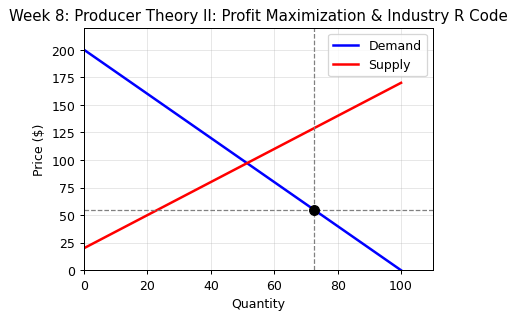

In [ ]:
# Supply & demand plot — output pre-rendered for viewer testing
P_range <- seq(0, 100, by = 0.5)
Qd <- 200 - 2 * P_range
Qs <- 20 + 1.5 * P_range
plot(Qd, P_range, type='l', col='blue', lwd=2,
     xlab='Quantity', ylab='Price', main='Supply & Demand')
lines(Qs, P_range, col='red', lwd=2)
legend('topright', c('Demand','Supply'), col=c('blue','red'), lty=1)

## Viewer Test: Empty Cell

The cell below is intentionally empty — the viewer should skip it gracefully.